<a href="https://colab.research.google.com/github/bikebhunia/My_Liner_Regression_Model/blob/main/logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas scikit-learn matplotlib

In [3]:
import numpy as np # handle numerical data
import pandas as pd # handle tabular data.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt # to visualize the results.


In [5]:
# Sample dataset : Study hours v/s Pass/Fail
data = {
    'StudyHours' : [1,2,3,4,5,6,7,8,9,10], # Feature vector
    'Pass' : [0,0,0,0,1,1,1,1,1,1] # Target label
}
# Convert to DataFrame
tabular_form = pd.DataFrame(data)
print(tabular_form)

   StudyHours  Pass
0           1     0
1           2     0
2           3     0
3           4     0
4           5     1
5           6     1
6           7     1
7           8     1
8           9     1
9          10     1


In [6]:
X = tabular_form[['StudyHours']] # feature
y = tabular_form[['Pass']] # Target variable (0->fail, 1->pass)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

# Display the shape of the training and testing sets
print(f"Training data: {X_train.shape}, {y_train.shape}") # First 7 rows
print(f"Testing data: {X_test.shape},{y_test.shape}") # last 3 rows

Training data: (7, 1), (7, 1)
Testing data: (3, 1),(3, 1)


In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

Intercept: [-4.75557568]
Coefficient: [1.02595947]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:
y_pred = model.predict(X_test)

print("Predicted Outcomes (Pass/Fail): ",y_pred)
print("Actual Outcomes: ",y_test.values)

Predicted Outcomes (Pass/Fail):  [1 0 1]
Actual Outcomes:  [[1]
 [0]
 [1]]


In [10]:
# Model Evaluation
accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix: \n{conf_matrix}")
print(f"Classification Report: \n{class_report}")

Accuracy: 1.0
Confusion Matrix: 
[[1 0]
 [0 2]]
Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


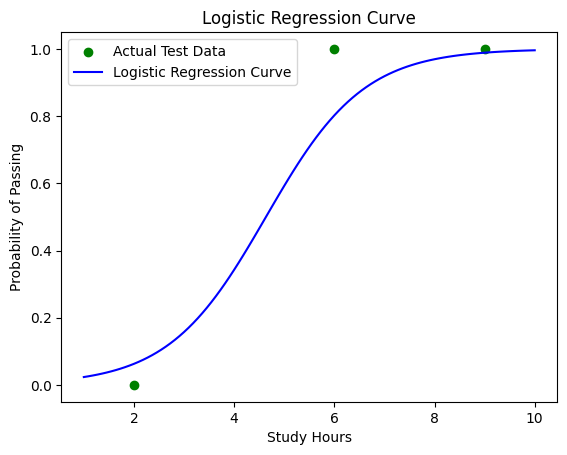

In [11]:
## Visualizatization
# Create a range of study hours for plotting
study_hours_range = np.linspace(X.min(),X.max(),100)
# Calculate predicted probabilities using the sigmoid function
y_prob = model.predict_proba(study_hours_range.reshape(-1,1))[:,1]
# Plot actuall data
plt.scatter(X_test,y_test,color='green',label='Actual Test Data')
# Plot logistic regression curve
plt.plot(study_hours_range,y_prob,color = 'blue',label='Logistic Regression Curve')
plt.xlabel('Study Hours')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression Curve')
plt.legend()

# Show the plot
plt.show()
